In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [6]:
class GraphState(TypedDict):
    num1: int
    op1: str
    num2: int
    finalNum1: int
    num3: int
    op2: str
    finalNum2: int

In [8]:
def add1(state: GraphState) -> GraphState:
    state["finalNum1"] = state["num1"] + state["num2"]
    return state


def subtract1(state: GraphState) -> GraphState:
    state["finalNum1"] = state["num1"] - state["num2"]
    return state


def decide_next_node1(state: GraphState):
    if state["op1"] == "+":
        return "add_operations1"
    elif state["op1"] == "-":
        return "subtract_operations1"


def add2(state: GraphState) -> GraphState:
    state["finalNum2"] = state["finalNum1"] + state["num3"]
    return state


def subtract2(state: GraphState) -> GraphState:
    state["finalNum2"] = state["finalNum1"] - state["num3"]
    return state


def decide_next_node2(state: GraphState):
    if state["op2"] == "+":
        return "add_operations2"
    elif state["op2"] == "-":
        return "subtract_operations2"

In [12]:
graph= StateGraph(GraphState)

graph.add_node("add1_node", add1)
graph.add_node("subtract1_node", subtract1)

graph.add_node("router1", lambda state: state)

graph.add_edge(START, "router1")

graph.add_conditional_edges(
  "router1",
  decide_next_node1,
  {
    "add_operations1": "add1_node",
    "subtract_operations1": "subtract1_node"
  }
)

graph.add_node("finalNum1", lambda state: state)

graph.add_edge("add1_node", "finalNum1")
graph.add_edge("subtract1_node", "finalNum1")

graph.add_conditional_edges(
  "finalNum1",
  decide_next_node2,
  {
    "add_operations2": "add2_node",
    "subtract_operations2": "subtract2_node"
  }
)

graph.add_node("add2_node", add2)
graph.add_node("subtract2_node", subtract2)

graph.add_edge("add2_node", END)
graph.add_edge("subtract2_node", END)

app = graph.compile()

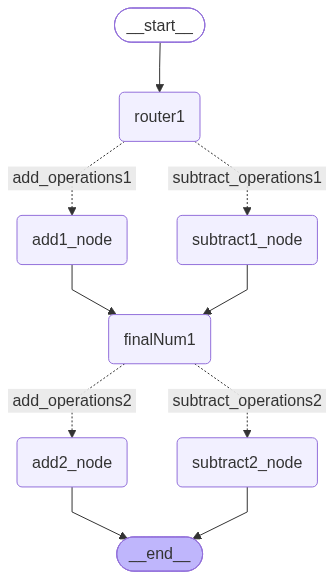

In [13]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
initial_state= GraphState(num1=10, op1="+", num2=5, num3= 3, op2= "-")
print(app.invoke(initial_state))  # This will perform addition and return the final state

{'num1': 10, 'op1': '+', 'num2': 5, 'finalNum1': 15, 'num3': 3, 'op2': '-', 'finalNum2': 12}
